# Cognifyz Data Analysis Internship

# Level 2 - Task 4 : Restaurant Chains Analysis

## Objectives

• Identify restaurant chains

• Analyze chain popularity

• Compare average ratings

• Discover top-performing chains

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(

    style='whitegrid',

    context='talk'

)

df = pd.read_csv("../Dataset.csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Identifying Restaurant Chains

In [2]:
chains = (

    df['Restaurant Name']

    .value_counts()

)

chains.head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [3]:
top_chains = chains.head(10)

top_chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

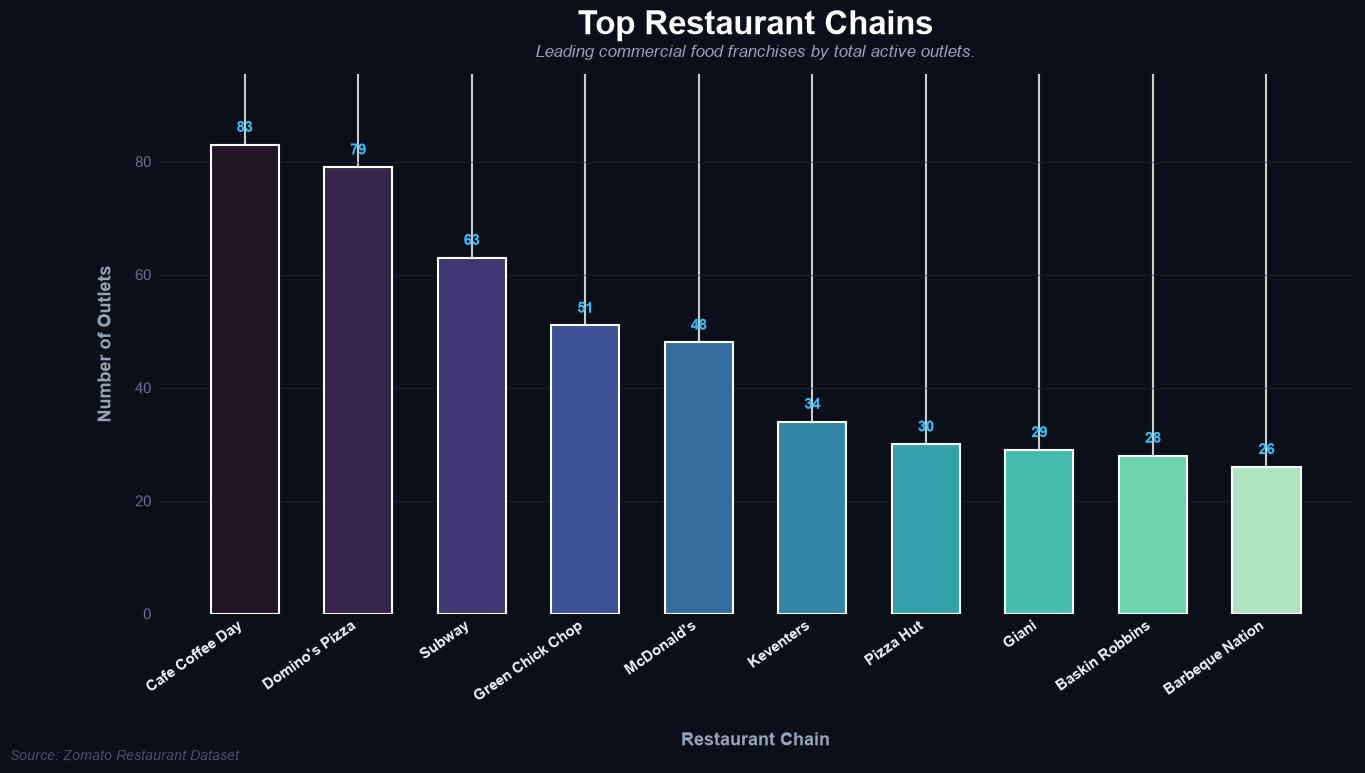

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8), facecolor="#0B0F19")
ax.set_facecolor("#0B0F19")

colors = sns.color_palette("mako", len(top_chains))

bars = ax.bar(
    top_chains.index,
    top_chains.values,
    color=colors,
    width=0.6,
    zorder=3
)

max_val = top_chains.values.max() if len(top_chains) > 0 else 100
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#38BDF8",
        zorder=4
    )

ax.text(
    0.5, 1.09, "Top Restaurant Chains",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=24, fontweight="bold", color="#FFFFFF"
)
ax.text(
    0.5, 1.04, "Leading commercial food franchises by total active outlets.",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=12, color="#94A3B8", style="italic"
)

ax.set_xlabel("Restaurant Chain", fontsize=13, fontweight="bold", labelpad=20, color="#94A3B8")
ax.set_ylabel("Number of Outlets", fontsize=13, fontweight="bold", labelpad=15, color="#94A3B8")

plt.xticks(rotation=35, ha="right", fontsize=11, fontweight="bold", color="#E2E8F0")
plt.yticks(fontsize=11, color="#64748B")

ax.set_ylim(0, max_val * 1.15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="y", linestyle="-", linewidth=0.8, color="#1E293B", alpha=0.6, zorder=0)
ax.tick_params(axis='both', which='both', length=0)

plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#475569"
)

plt.tight_layout()
plt.show()

## Average Rating of Popular Chains

In [5]:
rating_chain = (

    df.groupby(

        'Restaurant Name'

    )['Aggregate rating']

    .mean()

)

rating_chain = rating_chain.loc[

    top_chains.index

]

rating_chain

Restaurant Name
Cafe Coffee Day     2.419277
Domino's Pizza      2.740506
Subway              2.907937
Green Chick Chop    2.672549
McDonald's          3.339583
Keventers           2.870588
Pizza Hut           3.320000
Giani               2.689655
Baskin Robbins      1.860714
Barbeque Nation     4.353846
Name: Aggregate rating, dtype: float64

C:\Users\offic\AppData\Local\Temp\ipykernel_27812\2101175441.py:66: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\offic\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


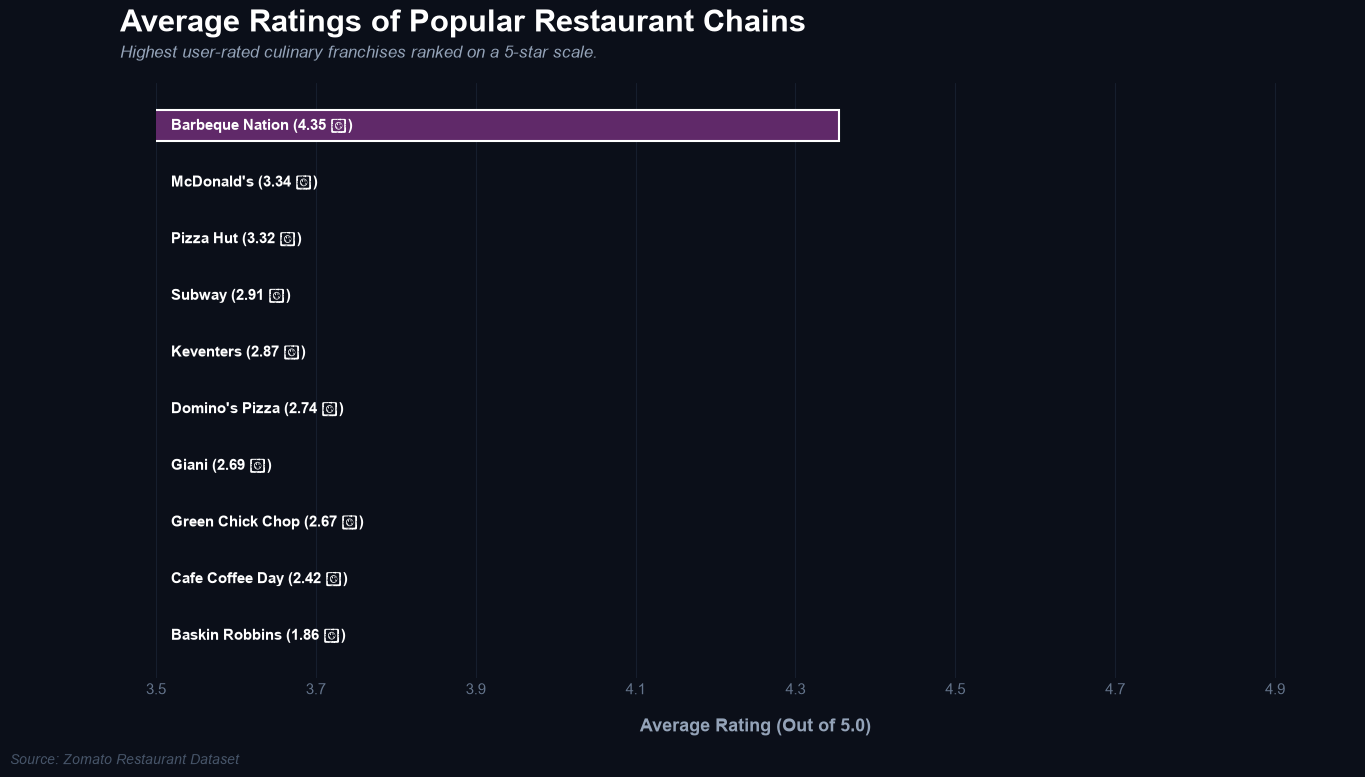

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

rating_chain = rating_chain.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 8), facecolor="#0B0F19")
ax.set_facecolor("#0B0F19")

colors = sns.color_palette("flare", len(rating_chain))

bars = ax.barh(
    rating_chain.index,
    rating_chain.values,
    color=colors,
    height=0.55,
    zorder=3
)

for i, bar in enumerate(bars):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    chain_name = rating_chain.index[i]
    
    ax.annotate(
        f"  {chain_name} ({width:.2f} ★)",
        xy=(3.5, y_pos),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        zorder=4
    )

ax.set_yticks([])

ax.text(
    -0.03, 1.10, "Average Ratings of Popular Restaurant Chains",
    transform=ax.transAxes, ha="left", va="center", fontsize=22, fontweight="bold", color="#FFFFFF"
)
ax.text(
    -0.03, 1.05, "Highest user-rated culinary franchises ranked on a 5-star scale.",
    transform=ax.transAxes, ha="left", va="center", fontsize=12, color="#94A3B8", style="italic"
)

ax.set_xlim(3.5, 5.0)
ax.set_xticks(np.arange(3.5, 5.1, 0.2))

ax.set_xlabel("Average Rating (Out of 5.0)", fontsize=13, fontweight="bold", labelpad=15, color="#94A3B8")
plt.xticks(fontsize=11, color="#64748B")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", linestyle="-", linewidth=0.8, color="#1E293B", alpha=0.6, zorder=0)
ax.tick_params(axis='both', which='both', length=0)

plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#475569"
)

plt.tight_layout()
plt.show()

# Key Insights

• Some restaurant brands operate through numerous outlets.

• Popular chains maintain fairly consistent ratings.

• High outlet count does not necessarily guarantee higher ratings.

• Chain analysis helps understand brand presence and customer satisfaction.

# Conclusion

Restaurant chain analysis reveals market dominance patterns and customer preferences.

Several chains maintain both strong brand presence and positive ratings, indicating successful business strategies.